# Step 0: Import the library

In [3]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl
import torch
from sklearn.preprocessing import MinMaxScaler
from xanfis.models.classic_anfis import AnfisRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Define the Universe of Discourse

In [22]:
# Input
Distance = ctrl.Antecedent(np.arange(0, 101, 1), 'Distance')
Angle = ctrl.Antecedent(np.arange(-90, 91, 1), 'Angle')

# Output
Speed = ctrl.Consequent(np.arange(0, 101, 1), 'Speed')
Turn = ctrl.Consequent(np.arange(-90, 90, 1), 'Turn')

# Step 2: Define Membership Functions

In [27]:
# .universe refers to the range of values that the variable can take
Distance['Close'] = fuzz.trapmf(Distance.universe, [0, 0, 30, 50])
Distance['Medium'] = fuzz.trapmf(Distance.universe, [25, 40, 60, 75])
Distance['Far'] = fuzz.trapmf(Distance.universe, [50, 75, 100, 100])

Angle['Left'] = fuzz.trimf(Angle.universe, [-90, -90, -30])
Angle['Front'] = fuzz.trimf(Angle.universe, [-45, 0, 45])
Angle['Right'] = fuzz.trimf(Angle.universe, [30, 90, 90])

Speed['Slow'] = fuzz.trimf(Speed.universe, [0, 0, 40])
#Speed['Medium'] = fuzz.trimf(Speed.universe, [25, 50, 75])
Speed['Medium'] = fuzz.trapmf(Speed.universe, [30, 40, 60, 70])
Speed['Fast'] = fuzz.trimf(Speed.universe, [60, 100, 100])

Turn['Right'] = fuzz.trimf(Turn.universe, [-90, -90, 0])
Turn['Straight'] = fuzz.trimf(Turn.universe, [-15, 0, 15])
Turn['Left'] = fuzz.trimf(Turn.universe, [0, 90, 90])

# Turn['Right'] = fuzz.gaussmf(Turn.universe, -60, 30)   # غير الوسط ليكون -60 مثلاً
# Turn['Straight'] = fuzz.gaussmf(Turn.universe, 0, 20)
# Turn['Left'] = fuzz.gaussmf(Turn.universe, 60, 30)



# Step 3: Define the Rules

- القاعدة 1: إذا كانت المسافة قريبة والزاوية إلى اليسار، فإن السرعة تكون بطيئة والتوجيه إلى اليسار.
- القاعدة 2: إذا كانت المسافة قريبة والزاوية أمام، فإن السرعة تكون بطيئة والتوجيه مستقيم.
- القاعدة 3: إذا كانت المسافة قريبة والزاوية إلى اليمين، فإن السرعة تكون بطيئة والتوجيه إلى اليمين.

- القاعدة 4: إذا كانت المسافة متوسطة والزاوية إلى اليسار، فإن السرعة تكون متوسطة والتوجيه إلى اليسار.
- القاعدة 5: إذا كانت المسافة متوسطة والزاوية أمام، فإن السرعة تكون متوسطة والتوجيه مستقيم.
- القاعدة 6: إذا كانت المسافة متوسطة والزاوية إلى اليمين، فإن السرعة تكون متوسطة والتوجيه إلى اليمين.

- القاعدة 7: إذا كانت المسافة بعيدة والزاوية إلى اليسار، فإن السرعة تكون سريعة والتوجيه إلى اليسار.
- القاعدة 8: إذا كانت المسافة بعيدة والزاوية أمام، فإن السرعة تكون سريعة والتوجيه مستقيم.
- القاعدة 9: إذا كانت المسافة بعيدة والزاوية إلى اليمين، فإن السرعة تكون سريعة والتوجيه إلى اليمين.

In [32]:
#rule1 = ctrl.Rule(dirt_amount['low'] & cloth_amount['small'] & dirt_type['light'], washing_time['short'])

rule1 = ctrl.Rule(Distance['Close'] & Angle['Left'], (Speed['Slow'], Turn['Left']))
rule2 = ctrl.Rule(Distance['Close'] & Angle['Front'], (Speed['Slow'], Turn['Straight']))
rule3 = ctrl.Rule(Distance['Close'] & Angle['Right'], (Speed['Slow'], Turn['Right']))

rule4 = ctrl.Rule(Distance['Medium'] & Angle['Left'], (Speed['Medium'], Turn['Left']))
rule5 = ctrl.Rule(Distance['Medium'] & Angle['Front'], (Speed['Medium'], Turn['Straight']))
rule6 = ctrl.Rule(Distance['Medium'] & Angle['Right'], (Speed['Medium'], Turn['Right']))

rule7 = ctrl.Rule(Distance['Far'] & Angle['Left'], (Speed['Fast'], Turn['Left']))
rule8 = ctrl.Rule(Distance['Far'] & Angle['Front'], (Speed['Fast'], Turn['Straight']))
rule9 = ctrl.Rule(Distance['Far'] & Angle['Right'], (Speed['Fast'], Turn['Right']))

# Step 4: Create the Control System

In [35]:
#ControlSystem initializes the system with the defined rules.
#ControlSystemSimulation creates an instance for running simulations.
washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
washing_simulation = ctrl.ControlSystemSimulation(washing_ctrl)

speed_turn_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
speed_turn_sim = ctrl.ControlSystemSimulation(speed_turn_ctrl)

# Step 5: Input Example Values

In [38]:
speed_turn_sim.input['Distance'] = 0   # مثال: 40 سم
speed_turn_sim.input['Angle'] = -90  

# Step 6: Compute the Output

In [41]:
speed_turn_sim.compute()

In [43]:
#print(f"Recommended washing time (Mamdani): {washing_simulation.output['washing_time']:.2f} minutes")
print(f"Speed: {speed_turn_sim.output['Speed']:.2f}")
print(f"Turn: {speed_turn_sim.output['Turn']:.2f} degrees")

Speed: 13.33
Turn: 59.33 degrees


# Step 7: Visulization

plt.figure(figsize=(12, 10))
plt.title(".............................. Visulization ..............................", pad=30)
# Distance
plt.subplot(4,1,1)
plt.plot(Distance.universe, Distance['Close'].mf, 'b', label='Close')
plt.plot(Distance.universe, Distance['Medium'].mf, color='orange', label='Medium')
plt.plot(Distance.universe, Distance['Far'].mf, 'r', label='Far')
plt.xticks(range(int(min(Distance.universe)), int(max(Distance.universe)) + 1, 5))
plt.title('Distance Membership Functions')
plt.xlabel('Distance (cm)')
plt.ylabel('Membership Degree')
plt.legend()

# Angle
plt.subplot(4,1,2)
plt.plot(Angle.universe, Angle['Left'].mf, 'b', label='Left')
plt.plot(Angle.universe, Angle['Front'].mf, color='orange', label='Front')
plt.plot(Angle.universe, Angle['Right'].mf, 'r', label='Right')
plt.xticks(range(-90, 91, 10))
plt.title('Angle Membership Functions')
plt.xlabel('Angle (degrees)')
plt.ylabel('Membership Degree')
plt.legend()

# Speed
plt.subplot(4,1,3)
plt.plot(Speed.universe, Speed['Slow'].mf, 'b', label='Slow')
plt.plot(Speed.universe, Speed['Medium'].mf, color='orange', label='Medium')
plt.plot(Speed.universe, Speed['Fast'].mf, 'r', label='Fast')
plt.xticks(range(int(min(Speed.universe)), int(max(Speed.universe)) + 1, 5))
plt.title('Speed Membership Functions')
plt.xlabel('Speed')
plt.ylabel('Membership Degree')
plt.legend()

# Turn
plt.subplot(4,1,4)
plt.plot(Turn.universe, Turn['Right'].mf, 'b', label='Right')
plt.plot(Turn.universe, Turn['Straight'].mf, color='orange', label='Straight')
plt.plot(Turn.universe, Turn['Left'].mf, 'r', label='Left')
plt.xticks(range(-90, 91, 10))
plt.title('Turn Membership Functions')
plt.xlabel('Turn Angle (degrees)')
plt.ylabel('Membership Degree')
plt.legend()

plt.tight_layout()
plt.subplots_adjust(hspace=1)
plt.show()

# Step 8: Build the Dataset

In [193]:
# مثال لتوليد بيانات تدريبية من النظام الحالي
X = []
Y = []
for d in range(0, 101, 1):      # كل القيم من 0 إلى 100
    for a in range(-90, 91, 1): # كل القيم من -90 إلى 90
        speed_turn_sim.input['Distance'] = d
        speed_turn_sim.input['Angle'] = a
        speed_turn_sim.compute()
        X.append([d, a])
        Y.append([speed_turn_sim.output['Speed'], speed_turn_sim.output['Turn']])
X = np.array(X)
Y = np.array(Y)


In [153]:
X

array([[  0, -90],
       [  0, -89],
       [  0, -88],
       ...,
       [100,  88],
       [100,  89],
       [100,  90]])

In [157]:
from sklearn.utils import shuffle
X,Y = shuffle(X, Y, random_state=42)

In [159]:
X

array([[ 11,  76],
       [ 79, -76],
       [ 34, -38],
       ...,
       [ 29,  51],
       [  4,  46],
       [ 87, -42]])

In [48]:
df = pd.DataFrame(
    np.hstack((X, Y)),   # دمج المصفوفات أفقياً
    columns=['Distance', 'Angle', 'Speed', 'Turn']  # أسماء الأعمدة
)

df

,Distance,Angle,Speed,Turn
0,0.0,-90.0,13.333333,59.333333
1,0.0,-89.0,13.336976,59.332402
2,0.0,-88.0,13.347670,59.318681
3,0.0,-87.0,13.365079,59.289189
4,0.0,-86.0,13.388889,59.244681
...,...,...,...,...
18276,100.0,86.0,86.611111,-59.875000
18277,100.0,87.0,86.634921,-59.928571
18278,100.0,88.0,86.652330,-59.967742
18279,100.0,89.0,86.663024,-59.991803


In [49]:
df.to_csv('speed_turn.csv', index = False)

In [290]:
data = pd.read_csv('speed_turn.csv')

# اختر العمودين الأوليين كمدخلات X
X = data[['Distance', 'Angle']].values

# اختر العمودين الأخيرين كمخرجات Y
Y = data[['Speed', 'Turn']].values

# تأكد من أن X و Y هما مصفوفتان من نوع numpy
X = np.array(X)
Y = np.array(Y)

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (18281, 2)
Y shape: (18281, 2)


# Step 9: Devid the dataset to train & test 

In [292]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات بنسبة 80% تدريب و 20% اختبار
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (14624, 2)
X_test shape: (3657, 2)
Y_train shape: (14624, 2)
Y_test shape: (3657, 2)


In [294]:
X_train

array([[ 22.,  -3.],
       [  2.,  90.],
       [ 43., -45.],
       ...,
       [ 29.,  51.],
       [  4.,  46.],
       [ 87., -42.]])

In [296]:
Y_train

array([[ 1.33888889e+01, -1.82145965e-16],
       [ 1.33333333e+01, -6.00000000e+01],
       [ 3.43892944e+01,  4.98536977e+01],
       ...,
       [ 3.20503928e+01, -5.23181818e+01],
       [ 1.74700855e+01, -5.06923077e+01],
       [ 8.19259259e+01,  4.51275081e+01]])

# Step 10: Applay Preprocessing 

In [298]:
# X = [[Distance, Angle], ...]
# Y = [[Speed, Turn], ...]

# تعريف Scaler للمدخلات
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X_train)

# تعريف Scaler للمخرجات
scaler_Y = MinMaxScaler(feature_range=(0, 1))
Y_scaled = scaler_Y.fit_transform(Y_train)

# Step 11: Build the Model

In [300]:
# إنشاء نموذج ANFIS
model = AnfisRegressor(
    num_rules=9,       
    mf_class="Triangular",
    epochs=50,         # زيادة عدد epochs
    batch_size=128,
    optim="Adam",
     optim_params={"lr": 0.1},
    verbose=True,
)
model = AnfisRegressor(
    num_rules=9,
    mf_class="Triangular",
    epochs=100,
    batch_size=128,
    optim_params={"lr": 0.0005}, #يحدد حجم الخطوة التي يتخذها المُحسّن في اتجاه التدرج المعاكس لتقليل الخسارة
    optim="Adam", # هي الخوارزمية التي تُطبق الانتشار الخلفي لتحديث أوزان النموذج. Adam
    valid_rate=0.3,        # 20% من البيانات للتحقق
    early_stopping=True,   # تفعيل الإيقاف المبكر
    n_patience=10,         # الانتظار 10 دورات بدون تحسن
    epsilon=0.001,         # حد التحسن المقبول
    verbose=True
)
# تدريب النموذج
model.fit(X_scaled, Y_scaled)

# التنبؤ
train_scaled = scaler_X.transform(X_train)
pred_scaled = model.predict(train_scaled)

# إعادة التحويل للنطاق الأصلي
pred = scaler_Y.inverse_transform(pred_scaled)

print(pred)


Epoch: 1, Train Loss: 0.012286, Validation Loss: 0.014952
Epoch: 2, Train Loss: 0.011938, Validation Loss: 0.015425
Epoch: 3, Train Loss: 0.013808, Validation Loss: 0.029031
Epoch: 4, Train Loss: 0.014860, Validation Loss: 0.017686
Epoch: 5, Train Loss: 0.014639, Validation Loss: 0.016166
Epoch: 6, Train Loss: 0.014229, Validation Loss: 0.016771
Epoch: 7, Train Loss: 0.014608, Validation Loss: 0.017386
Epoch: 8, Train Loss: 0.013781, Validation Loss: 0.015425
Epoch: 9, Train Loss: 0.013339, Validation Loss: 0.015044
Epoch: 10, Train Loss: 0.011856, Validation Loss: 0.014748
Epoch: 11, Train Loss: 0.011500, Validation Loss: 0.013324
Epoch: 12, Train Loss: 0.009973, Validation Loss: 0.012146
Epoch: 13, Train Loss: 0.009195, Validation Loss: 0.010591
Epoch: 14, Train Loss: 0.007005, Validation Loss: 0.008185
Epoch: 15, Train Loss: 0.005900, Validation Loss: 0.007872
Epoch: 16, Train Loss: 0.005829, Validation Loss: 0.007863
Epoch: 17, Train Loss: 0.005815, Validation Loss: 0.009851
Epoch:

# Step 12: Train the model

In [301]:
# بعد التنبؤ
pred_scaled_traina = model.predict(X_scaled)
pred_original_train = scaler_Y.inverse_transform(pred_scaled_traina)  # إعادة النطاق الأصلي

rmse_original = np.sqrt(np.mean((pred_original_train - Y_train)**2))
mse = mean_squared_error(Y_train, pred_original_train)
mae = mean_absolute_error(Y_train, pred_original_train)
r2 = r2_score(Y_train, pred_original_train)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)
print("Training RMSE (original scale):", rmse_original)

MSE: 42.01826253246155
MAE: 1.9674497068106218
R²: 0.9738878179723227
Training RMSE (original scale): 6.482149530245474


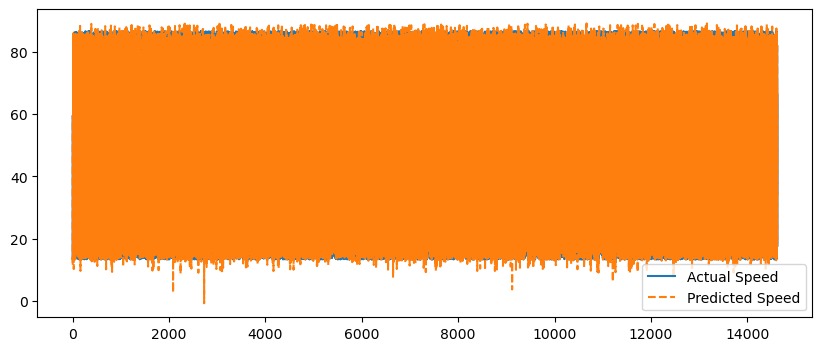

In [302]:
plt.figure(figsize=(10,4))
plt.plot(Y_train[:,0], label="Actual Speed")
plt.plot(pred_original_train[:,0], '--', label="Predicted Speed")
plt.legend()
plt.show()

# Step 13: Test the model

In [303]:
X_scaled_test = scaler_X.transform(X_test)

# تعريف Scaler للمخرجات
Y_scaled_test = scaler_Y.transform(Y_test)

In [304]:
# بعد التنبؤ
pred_scaled_test = model.predict(X_scaled_test)
pred_original_test = scaler_Y.inverse_transform(pred_scaled_test)  # إعادة النطاق الأصلي

rmse_original = np.sqrt(np.mean((pred_original_test - Y_test)**2))
mse = mean_squared_error(Y_test, pred_original_test)
mae = mean_absolute_error(Y_test, pred_original_test)
r2 = r2_score(Y_test, pred_original_test)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)
print("Training RMSE (original scale):", rmse_original)

MSE: 54.44898823967775
MAE: 2.098042739361089
R²: 0.9668990541250294
Training RMSE (original scale): 7.3789557689200125


In [305]:
Y_test

array([[ 13.92192192, -58.67567568],
       [ 86.07807808,  58.11009174],
       [ 34.61256762,  36.0031072 ],
       ...,
       [ 63.26758568, -52.94329897],
       [ 81.77166157, -43.6893715 ],
       [ 65.106955  ,  56.95762712]])

# Step 14: Visulization the model

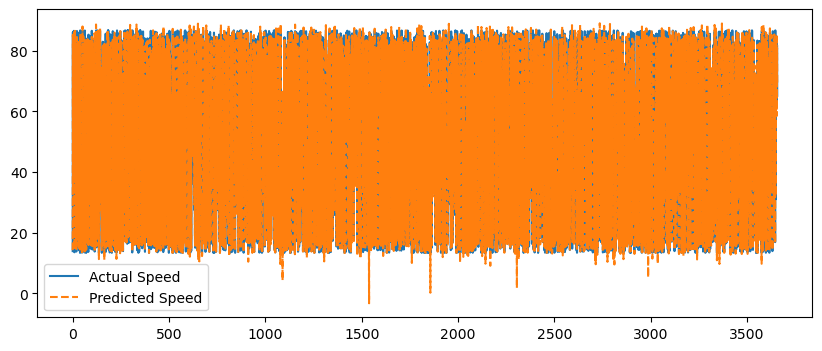

In [306]:
plt.figure(figsize=(10,4))
plt.plot(Y_test[:,0], label="Actual Speed")
plt.plot(pred_original_test[:,0], '--', label="Predicted Speed")
plt.legend()
plt.show()

In [318]:
print(pred_original_train.shape, pred_original_test.shape)
print(Y_train.shape, Y_test.shape)

(14624, 2) (3657, 2)
(14624, 2) (3657, 2)


In [368]:
X_train

array([[ 22.,  -3.],
       [  2.,  90.],
       [ 43., -45.],
       ...,
       [ 29.,  51.],
       [  4.,  46.],
       [ 87., -42.]])

In [366]:
Y_train

array([[ 1.33888889e+01, -1.82145965e-16],
       [ 1.33333333e+01, -6.00000000e+01],
       [ 3.43892944e+01,  4.98536977e+01],
       ...,
       [ 3.20503928e+01, -5.23181818e+01],
       [ 1.74700855e+01, -5.06923077e+01],
       [ 8.19259259e+01,  4.51275081e+01]])

In [328]:
pred_original_train

array([[ 14.154353 ,   1.1697338],
       [ 11.45054  , -64.07694  ],
       [ 40.12542  ,  47.75826  ],
       ...,
       [ 32.31588  , -50.001747 ],
       [ 18.45166  , -51.856922 ],
       [ 82.02599  ,  43.52731  ]], dtype=float32)

In [362]:
Y_test

array([[ 13.92192192, -58.67567568],
       [ 86.07807808,  58.11009174],
       [ 34.61256762,  36.0031072 ],
       ...,
       [ 63.26758568, -52.94329897],
       [ 81.77166157, -43.6893715 ],
       [ 65.106955  ,  56.95762712]])

In [364]:
pred_original_test

array([[ 14.249156, -59.022934],
       [ 85.19742 ,  58.898235],
       [ 34.07441 ,  36.091167],
       ...,
       [ 58.513874, -52.955475],
       [ 80.84947 , -44.46245 ],
       [ 69.40104 ,  56.95549 ]], dtype=float32)

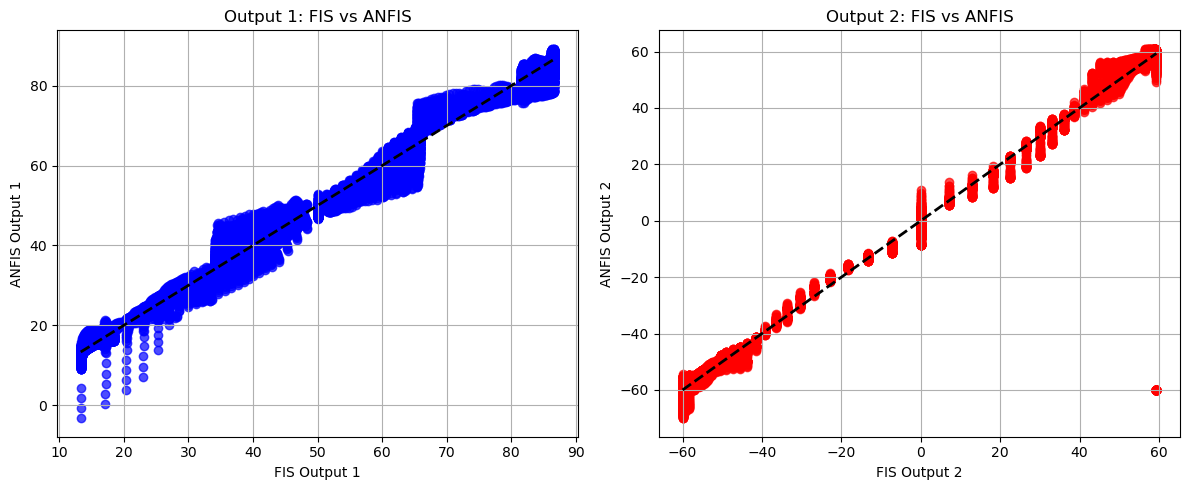

In [460]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# المقارنة للمخرج الأول
axs[0].scatter(Y[:, 0], pred_original_graph[:, 0], color='blue', alpha=0.7)
axs[0].plot([Y[:, 0].min(), Y[:, 0].max()],
            [Y[:, 0].min(), Y[:, 0].max()],
            'k--', lw=2)  # الخط المرجعي y=x
axs[0].set_title('Output 1: FIS vs ANFIS')
axs[0].set_xlabel('FIS Output 1')
axs[0].set_ylabel('ANFIS Output 1')
axs[0].grid(True)

# المقارنة للمخرج الثاني
axs[1].scatter(Y[:, 1], pred_original_graph[:, 1], color='red', alpha=0.7)
axs[1].plot([Y[:, 1].min(), Y[:, 1].max()],
            [Y[:, 1].min(), Y[:, 1].max()],
            'k--', lw=2)  # الخط المرجعي y=x
axs[1].set_title('Output 2: FIS vs ANFIS')
axs[1].set_xlabel('FIS Output 2')
axs[1].set_ylabel('ANFIS Output 2')
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [450]:
graph =  scaler_X.transform(X)

pred_scaled_graph = model.predict(graph)
pred_original_graph = scaler_Y.inverse_transform(pred_scaled_graph) 

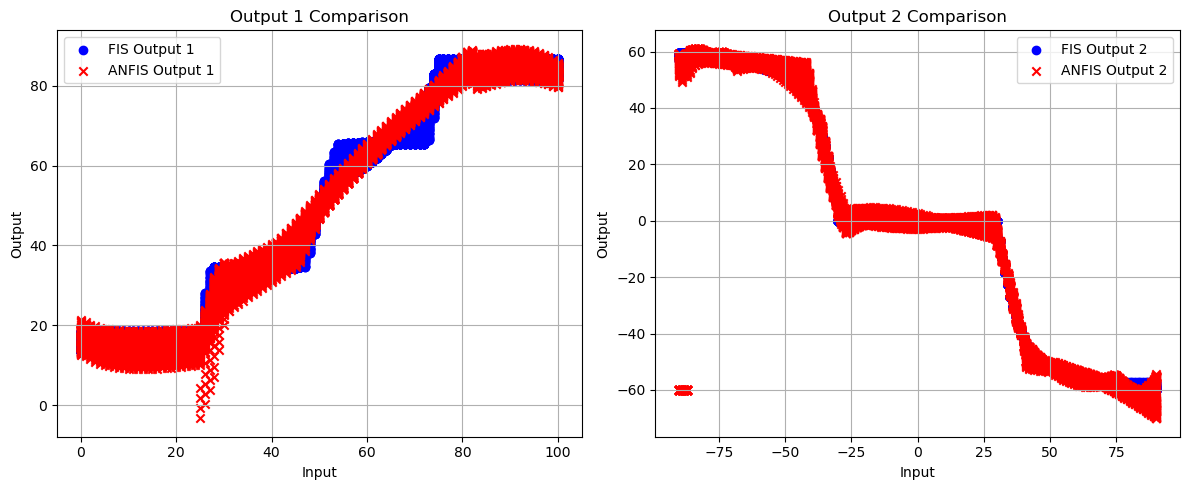

In [452]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# المخرج الأول
axs[0].scatter(X[:, 0], Y[:, 0], color='blue', label='FIS Output 1')
axs[0].scatter(X[:, 0], pred_original_graph[:, 0], color='red', marker='x', label='ANFIS Output 1')
axs[0].set_title('Output 1 Comparison')
axs[0].set_xlabel('Input')
axs[0].set_ylabel('Output')
axs[0].legend()
axs[0].grid(True)

# المخرج الثاني
axs[1].scatter(X[:, 1], Y[:, 1], color='blue', label='FIS Output 2')
axs[1].scatter(X[:, 1], pred_original_graph[:, 1], color='red', marker='x', label='ANFIS Output 2')
axs[1].set_title('Output 2 Comparison')
axs[1].set_xlabel('Input')
axs[1].set_ylabel('Output')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [416]:
graph =  scaler_X.transform(X_train)

pred_scaled_graph = model.predict(graph)
pred_original_graph = scaler_Y.inverse_transform(pred_scaled_graph) 

In [434]:
pred_original_graph

array([[ 14.154353 ,   1.1697338],
       [ 11.45054  , -64.07694  ],
       [ 40.12542  ,  47.75826  ],
       ...,
       [ 32.31588  , -50.001747 ],
       [ 18.45166  , -51.856922 ],
       [ 82.02599  ,  43.52731  ]], dtype=float32)

In [436]:
Y_train

array([[ 1.33888889e+01, -1.82145965e-16],
       [ 1.33333333e+01, -6.00000000e+01],
       [ 3.43892944e+01,  4.98536977e+01],
       ...,
       [ 3.20503928e+01, -5.23181818e+01],
       [ 1.74700855e+01, -5.06923077e+01],
       [ 8.19259259e+01,  4.51275081e+01]])

In [444]:
graph1 =  scaler_X.transform(X_test)

pred_scaled_graph1 = model.predict(graph1)
pred_original_graph1 = scaler_Y.inverse_transform(pred_scaled_graph1) 

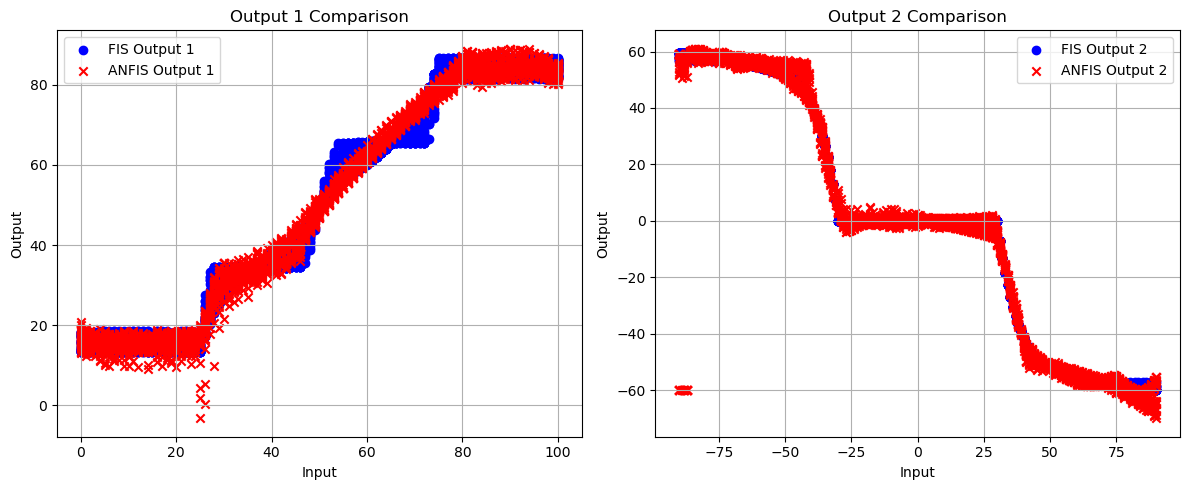

In [446]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# المخرج الأول
axs[0].scatter(X_test[:, 0], Y_test[:, 0], color='blue', label='FIS Output 1')
axs[0].scatter(X_test[:, 0], pred_original_graph1[:, 0], color='red', marker='x', label='ANFIS Output 1')
axs[0].set_title('Output 1 Comparison')
axs[0].set_xlabel('Input')
axs[0].set_ylabel('Output')
axs[0].legend()
axs[0].grid(True)

# المخرج الثاني
axs[1].scatter(X_test[:, 1], Y_test[:, 1], color='blue', label='FIS Output 2')
axs[1].scatter(X_test[:, 1], pred_original_graph1[:, 1], color='red', marker='x', label='ANFIS Output 2')
axs[1].set_title('Output 2 Comparison')
axs[1].set_xlabel('Input')
axs[1].set_ylabel('Output')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(model.evaluate(y_true=data.y_test, y_pred=y_pred, list_metrics=["R", "NSE", "MAPE", "KGE", "R2S", "R2"]))